In [8]:
import numpy as np
import matplotlib.pyplot as plt

# build model

In [23]:
# create grid
nx, nz = 200, 100
x = np.linspace(0, 80, nx)
z = np.linspace(40, 0, nz)
X, Z = np.meshgrid(x, z)

# create matrix of resistivity values
model = np.ones((nz, nx)) * 100 

# equation defining slope surface
slope_surface = 40 - 0.5 * x 

# airspace above slope
for i in range(nx):
    model[Z[:, i] > slope_surface[i], i] = np.nan

In [24]:
# low resistivity clay layer
for i in range(nx):
    for j in range(nz):
        if not np.isnan(model[j, i]):
            depth_from_surface = slope_surface[i] - Z[j, i]

            if 8 < depth_from_surface < 10:
                model[j, i] = 5

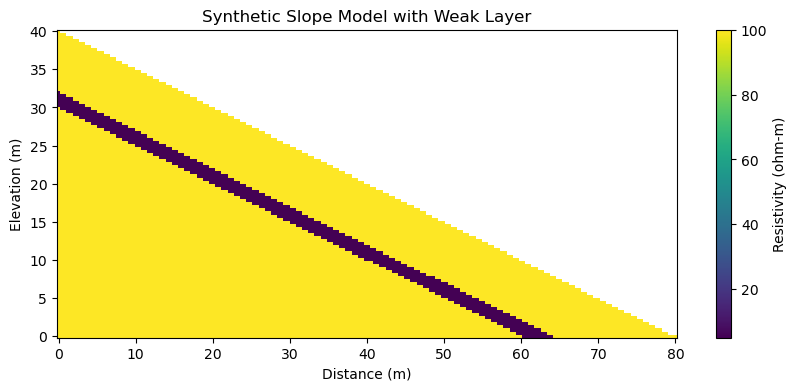

In [25]:
plt.figure(figsize=(10, 4))
plt.pcolormesh(X, Z, model, shading='auto')
plt.colorbar(label='Resistivity (ohm-m)')
plt.title('Synthetic Slope Model with Weak Layer')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.show()

In [ ]:
# air needs to be very resistive and needs to be inactive, 10^8
# need to capture boundary conditions with sensors, make sure mesh is large enough
# run forward problem w and w/o target to see if theres a diff